# Representation learning for easier drift

This experiment tests whether fully joint training produces a representation that helps a **new** generator learn drifting more easily.

Protocol:

1. Pretrain one VAE.
2. Copy that same pretrained VAE into a separate baseline and a fully joint model.
3. Train the fully joint model with Algorithm 3's re-encoded drift loss.
4. Freeze the pretrained baseline VAE and the joint-trained VAE/decoder.
5. Discard both original generators.
6. Train two brand-new generators from the same initialization, using the same latent warm-up, DriftXpress warm-up, epochs, and batch size.

The downstream comparison is therefore about the representation, not about which original generator happened to co-adapt with it. The notebook also records generation metrics, convergence/efficiency metrics, and drift-field statistics.


In [1]:
import copy
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

%cd "C:/Users/mateo/Desktop/polymath-jr-drifting"
from src.driftXpress import *
from src.eval import evaluate_generation, evaluate_latent_model, evaluate_mnist_generation, fit_mnist_evaluator, latent_statistics
from src.training import compose_objective, format_epoch_losses, gradient_report

torch.manual_seed(7)
np.random.seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


C:\Users\mateo\Desktop\polymath-jr-drifting
Using: cuda


In [2]:
transform = transforms.ToTensor()

SELECTED_DIGITS = (0, 8, 2, 4, 7, 9)
NUM_CLASSES = len(SELECTED_DIGITS)
CLASS_TO_DIGIT = np.asarray(SELECTED_DIGITS)
DIGIT_TO_CLASS = {digit: index for index, digit in enumerate(SELECTED_DIGITS)}

BATCH_SIZE = 500
LATENT_DIM = 32
NUM_LANDMARKS = 200
TEMPERATURE = 2
LAMBDA_KL = 1e-5
LAMBDA_DRIFT = 30.0
LAMBDA_VAR = 0.0
LAMBDA_COV = 0.0

VAE_PRETRAIN_EPOCHS = 100
JOINT_EPOCHS = 100
TRANSFER_LATENT_WARMUP_EPOCHS = 30
TRANSFER_DRIFT_WARMUP_EPOCHS = 25
TRANSFER_EPOCHS = 100
VAE_PRETRAIN_LR = 1e-3
JOINT_GENERATOR_LR = 1e-4
JOINT_VAE_LR = 3e-6
TRANSFER_GENERATOR_LR = 1e-4
JOINT_EARLY_STOP_PATIENCE = 15
JOINT_EARLY_STOP_MIN_DELTA = 1e-5

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

def keep_selected_digits(dataset):
    selected = torch.tensor(SELECTED_DIGITS, dtype=dataset.targets.dtype)
    mask = torch.isin(dataset.targets, selected)
    dataset.data = dataset.data[mask]
    raw_targets = dataset.targets[mask]
    dataset.targets = torch.tensor(
        [DIGIT_TO_CLASS[int(digit)] for digit in raw_targets], dtype=torch.long
    )
    return dataset

train_data = keep_selected_digits(train_data)
test_data = keep_selected_digits(test_data)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
print("Selected digits:", SELECTED_DIGITS)
print("Train samples:", len(train_data), "Test samples:", len(test_data))


Selected digits: (0, 8, 2, 4, 7, 9)
Train samples: 35788 Test samples: 6005


In [3]:
class FullModel(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32, num_classes=6, label_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, 96), nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(96, latent_dim)
        self.fc_var = nn.Linear(96, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 96), nn.LeakyReLU(0.2),
            nn.Linear(96, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, input_dim), nn.Sigmoid(),
        )
        self.embedding = nn.Embedding(num_classes, label_dim)
        self.generator = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, latent_dim),
        )

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)

    def get_latent(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_var(h)
        return mu, logvar, self.reparameterize(mu, logvar)

    def encode_mu(self, x):
        return self.fc_mu(self.encoder(x))

    def decode(self, z):
        return self.decoder(z)

    def generate(self, noise, labels):
        h = torch.cat([noise, self.embedding(labels.long())], dim=1)
        z = self.generator(h)
        return z, self.decode(z)


def vae_parameters(model):
    return list(model.encoder.parameters()) + list(model.fc_mu.parameters()) + list(model.fc_var.parameters()) + list(model.decoder.parameters())

def generator_parameters(model):
    return list(model.embedding.parameters()) + list(model.generator.parameters())


In [4]:
def build_conditional_cache(model, data_loader):
    """Build one deterministic class-conditional cache from encoder means."""
    model.eval()
    references = {class_id: [] for class_id in range(NUM_CLASSES)}
    with torch.no_grad():
        for images, labels in data_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            z = model.encode_mu(x)
            labels = labels.to(device, non_blocking=True)
            for class_id in range(NUM_CLASSES):
                mask = labels == class_id
                if mask.any():
                    references[class_id].append(z[mask].detach())

    cache = {}
    reference_bank = []
    for class_id in range(NUM_CLASSES):
        support = torch.cat(references[class_id], dim=0)
        reference_bank.append(support)
        landmarks = select_landmarks(support, NUM_LANDMARKS)
        W = build_nystrom_cache(landmarks, TEMPERATURE)
        A, b = pre_compute_summaries(support, landmarks, W, TEMPERATURE)
        cache[class_id] = (landmarks, W, A, b)
    return cache, torch.cat(reference_bank, dim=0)


def conditional_drift_loss(z, labels, cache):
    total = z.new_zeros(())
    field = torch.zeros_like(z)
    for class_tensor in torch.unique(labels):
        class_id = int(class_tensor.item())
        mask = labels == class_id
        landmarks, W, A, b = cache[class_id]
        loss, class_field = drift_loss(z[mask], landmarks, W, A, b, TEMPERATURE)
        total = total + mask.float().mean() * loss
        field[mask] = class_field
    return total, field


def drift_objective(z, labels, cache):
    L_drift, V = conditional_drift_loss(z, labels, cache)
    L_var = variance_loss(z)
    L_cov = covariance_loss(z)
    loss = LAMBDA_DRIFT * L_drift + LAMBDA_VAR * L_var + LAMBDA_COV * L_cov
    return loss, L_drift, L_var, L_cov, V


In [5]:
def pretrain_vae(model, epochs):
    """Pretrain only the VAE portion; this matches the separate baseline."""
    for parameter in generator_parameters(model):
        parameter.requires_grad_(False)
    for parameter in vae_parameters(model):
        parameter.requires_grad_(True)

    optimizer = optim.AdamW(vae_parameters(model), lr=VAE_PRETRAIN_LR)
    history = {key: [] for key in ("total", "recon", "kl", "var", "covar")}
    print(f"VAE pretraining for {epochs} epochs")
    for epoch in range(epochs):
        model.train()
        items = {key: 0.0 for key in history}
        for images, _ in train_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            mu, logvar, z = model.get_latent(x)
            reconstruction = model.decode(z)
            L_recon = recon_loss(reconstruction, x)
            L_kl = kl_loss(mu, logvar)
            L_var = variance_loss(mu)
            L_cov = covariance_loss(mu)
            loss = L_recon + LAMBDA_KL * L_kl + LAMBDA_VAR * L_var + LAMBDA_COV * L_cov
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae_parameters(model), 5.0)
            optimizer.step()
            items["total"] += loss.item()
            items["recon"] += L_recon.item()
            items["kl"] += L_kl.item()
            items["var"] += L_var.item()
            items["covar"] += L_cov.item()
        for key in items:
            items[key] /= len(train_loader)
            history[key].append(items[key])
        if epoch == 0 or (epoch + 1) % 10 == 0 or epoch + 1 == epochs:
            print(f"VAE epoch {epoch + 1}/{epochs}: total={items['total']:.6f} recon={items['recon']:.6f}")

    return history


def train_full_joint(model, cache, epochs):
    """Algorithm 3 after VAE pretraining, using the fixed pretrained cache."""
    for parameter in model.parameters():
        parameter.requires_grad_(True)
    optimizer = optim.AdamW([
        {"params": generator_parameters(model), "lr": JOINT_GENERATOR_LR},
        {"params": vae_parameters(model), "lr": JOINT_VAE_LR},
    ])
    print(f"Joint learning rates: generator={JOINT_GENERATOR_LR:g}, VAE={JOINT_VAE_LR:g}")

    # Fixed validation batch/noise make the stopping signal comparable across epochs.
    validation_images, validation_labels = next(iter(test_loader))
    validation_x = validation_images.to(device, non_blocking=True).flatten(start_dim=1)
    validation_labels = validation_labels.to(device, non_blocking=True)
    validation_generator = torch.Generator().manual_seed(12345)
    validation_noise = torch.randn(
        validation_x.shape[0], LATENT_DIM, generator=validation_generator
    ).to(device)

    history = {key: [] for key in ("total", "recon", "kl", "drift", "var", "covar", "force", "val_total", "val_recon", "val_drift")}
    best_state = copy.deepcopy(model.state_dict())
    best_score = float("inf")
    best_epoch = -1
    epochs_without_improvement = 0
    print(f"Fully joint training for {epochs} epochs")
    start = time.perf_counter()
    t0 = time.perf_counter()
    print("\n Full joint training started")
    for epoch in range(epochs):
        model.train()
        items = {key: 0.0 for key in ("total", "recon", "kl", "drift", "var", "covar", "force")}
        for images, labels in train_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            labels = labels.to(device, non_blocking=True)
            noise = torch.randn(x.shape[0], LATENT_DIM, device=device)
            mu, logvar, z_pos = model.get_latent(x)
            x_recon = model.decode(z_pos)
            _, x_neg = model.generate(noise, labels)
            z_neg = model.encode_mu(x_neg)
            L_drift, V = conditional_drift_loss(z_neg, labels, cache)
            L_recon = recon_loss(x_recon, x)
            L_kl = kl_loss(mu, logvar)
            L_var = variance_loss(mu) + variance_loss(z_neg)
            L_cov = covariance_loss(mu) + covariance_loss(z_neg)
            loss, _ = compose_objective(
                {"recon": L_recon, "kl": L_kl, "drift": L_drift, "var": L_var, "covar": L_cov},
                {"kl": LAMBDA_KL, "drift": LAMBDA_DRIFT, "var": LAMBDA_VAR, "covar": LAMBDA_COV},
            )
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            items["total"] += loss.item()
            items["recon"] += L_recon.item()
            items["kl"] += L_kl.item()
            items["drift"] += L_drift.item()
            items["var"] += L_var.item()
            items["covar"] += L_cov.item()
            items["force"] += V.norm(dim=1).mean().item()
        for key in items:
            items[key] /= len(train_loader)
            history[key].append(items[key])

        model.eval()
        with torch.no_grad():
            val_mu, val_logvar, val_z_pos = model.get_latent(validation_x)
            val_reconstruction = model.decode(val_z_pos)
            _, val_x_neg = model.generate(validation_noise, validation_labels)
            val_z_neg = model.encode_mu(val_x_neg)
            val_drift, _ = conditional_drift_loss(val_z_neg, validation_labels, cache)
            val_recon = recon_loss(val_reconstruction, validation_x)
            val_kl = kl_loss(val_mu, val_logvar)
            val_score = val_recon + LAMBDA_KL * val_kl + LAMBDA_DRIFT * val_drift

        history["val_total"].append(float(val_score.item()))
        history["val_recon"].append(float(val_recon.item()))
        history["val_drift"].append(float(val_drift.item()))
        if val_score.item() < best_score - JOINT_EARLY_STOP_MIN_DELTA:
            best_state = copy.deepcopy(model.state_dict())
            best_score = float(val_score.item())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 0 or (epoch + 1) % 10 == 0 or epoch + 1 == epochs:
            print(f"\n Epoch: {epoch + 1}/{epochs}")
            print(format_epoch_losses(
                {k: items[k] for k in ("recon", "kl", "drift", "var", "covar")},
                {"kl": LAMBDA_KL, "drift": LAMBDA_DRIFT, "var": LAMBDA_VAR, "covar": LAMBDA_COV},
            ))
            print(f"validation: total={val_score.item():.6f} recon={val_recon.item():.6f} drift={val_drift.item():.6f}")
            print("distances", torch.cdist(z_pos[:50], z_pos[:50]).mean().item())
            print(f"average |V|={items['force']:.6f}")

        if epochs_without_improvement >= JOINT_EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}; best validation epoch was {best_epoch + 1}.")
            break

    model.load_state_dict(best_state)
    print(f"Restored best joint model from epoch {best_epoch + 1} (validation total={best_score:.6f}).")
    elapsed = (time.perf_counter() - t0) / 60
    print(f"Finished. Training took {elapsed:.2f} minutes")
    history["wall_time_sec"] = time.perf_counter() - start
    history["best_epoch"] = best_epoch + 1
    history["epochs_run"] = len(history["total"])
    history["stopped_early"] = len(history["total"]) < epochs
    history["optimizer_steps"] = len(history["total"]) * len(train_loader)
    return history


In [6]:
# Use one identical pretrained VAE state for both representation sources.
base_model = FullModel(784, LATENT_DIM, NUM_CLASSES).to(device)
pretrain_history = pretrain_vae(base_model, VAE_PRETRAIN_EPOCHS)
cache_pretrained, _ = build_conditional_cache(base_model, train_loader)
pretrained_state = copy.deepcopy(base_model.state_dict())

# The joint model starts from exactly the same pretrained VAE state.
joint_model = FullModel(784, LATENT_DIM, NUM_CLASSES).to(device)
joint_model.load_state_dict(pretrained_state)
joint_history = train_full_joint(joint_model, cache_pretrained, JOINT_EPOCHS)

# Train one frozen MNIST evaluator for all post-training image metrics.
evaluator_train_images = train_data.data.float().div(255).unsqueeze(1)
mnist_evaluator = fit_mnist_evaluator(
    evaluator_train_images, train_data.targets, NUM_CLASSES,
    feature_dim=64, epochs=5, device=device, random_state=1234,
)

# This is the original co-adapted joint model, before discarding its generator.
original_joint_eval = evaluate_latent_model(
    joint_model, test_loader, device=device, n_samples=2048,
    n_classes=NUM_CLASSES, class_to_label=CLASS_TO_DIGIT,
    evaluator=mnist_evaluator, evaluator_batch_size=1024,
    include_mmd=False, include_fid=True,
)
print("Original co-adapted joint metrics:")
for name, value in original_joint_eval["metrics"].items():
    print(f"{name}: {value:.6f}")


VAE pretraining for 100 epochs
VAE epoch 1/100: total=0.094231 recon=0.093610
VAE epoch 10/100: total=0.020806 recon=0.019717
VAE epoch 20/100: total=0.013592 recon=0.012529
VAE epoch 30/100: total=0.010986 recon=0.009950
VAE epoch 40/100: total=0.009431 recon=0.008400
VAE epoch 50/100: total=0.008521 recon=0.007497
VAE epoch 60/100: total=0.007872 recon=0.006850
VAE epoch 70/100: total=0.007391 recon=0.006370
VAE epoch 80/100: total=0.007043 recon=0.006024
VAE epoch 90/100: total=0.006747 recon=0.005727
VAE epoch 100/100: total=0.006529 recon=0.005508
Joint learning rates: generator=0.0001, VAE=3e-06
Fully joint training for 100 epochs

 Full joint training started

 Epoch: 1/100
total=16.614448
representation=0.006808    scaled=0.006808
recon=0.005787    scaled=0.005787
kl=102.050452    scaled=0.001021
drift=0.553588    scaled=16.607640
var=1.827259    scaled=0.000000
covar=0.865912    scaled=0.000000
validation: total=13.232573 recon=0.006830 drift=0.440824
distances 8.7618370056152

In [7]:
def make_transfer_model(source_model, generator_state):
    """Copy only a source representation and attach a fresh common generator."""
    model = FullModel(784, LATENT_DIM, NUM_CLASSES).to(device)
    for name in ("encoder", "fc_mu", "fc_var", "decoder"):
        getattr(model, name).load_state_dict(getattr(source_model, name).state_dict())
    model.embedding.load_state_dict(generator_state["embedding"])
    model.generator.load_state_dict(generator_state["generator"])
    for parameter in vae_parameters(model):
        parameter.requires_grad_(False)
    for parameter in generator_parameters(model):
        parameter.requires_grad_(True)
    return model


# One generator initialization is shared by both frozen representations.
transfer_seed_model = FullModel(784, LATENT_DIM, NUM_CLASSES).to(device)
transfer_generator_state = {
    "embedding": copy.deepcopy(transfer_seed_model.embedding.state_dict()),
    "generator": copy.deepcopy(transfer_seed_model.generator.state_dict()),
}

separate_transfer = make_transfer_model(base_model, transfer_generator_state)
joint_transfer = make_transfer_model(joint_model, transfer_generator_state)

# Fixed inputs make the four visual checkpoints directly comparable.
evolution_noise = torch.randn(10, LATENT_DIM, device=device)
evolution_labels = torch.tensor([0, 1, 2, 3, 4, 5, 0, 1, 2, 3], device=device)


In [8]:
def snapshot_generation(model, stage):
    model.eval()
    with torch.no_grad():
        z, images = model.generate(evolution_noise, evolution_labels)
    return {"stage": stage, "latents": z.detach().cpu(), "images": images.detach().cpu()}


def train_new_generator(model, cache, name):
    """Identical downstream training for the separate and joint representations."""
    history = {key: [] for key in ("total", "drift", "var", "covar", "force")}
    evolution = []
    optimizer = optim.AdamW(generator_parameters(model), lr=TRANSFER_GENERATOR_LR)
    start = time.perf_counter()

    # Stage 1: identical latent-MSE warm-up for both representations.
    for epoch in range(TRANSFER_LATENT_WARMUP_EPOCHS):
        model.train()
        for images, labels in train_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            labels = labels.to(device, non_blocking=True)
            with torch.no_grad():
                target_mu = model.encode_mu(x)
            noise = torch.randn(x.shape[0], LATENT_DIM, device=device)
            z, _ = model.generate(noise, labels)
            loss = F.mse_loss(z, target_mu)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(generator_parameters(model), 5.0)
            optimizer.step()
        print(f"Latent warm-up epoch {epoch + 1}/{TRANSFER_LATENT_WARMUP_EPOCHS}")
    evolution.append(snapshot_generation(model, "after latent warm-up"))

    # Stage 2: identical DriftXpress warm-up.
    for epoch in range(TRANSFER_DRIFT_WARMUP_EPOCHS):
        model.train()
        for _, labels in train_loader:
            labels = labels.to(device, non_blocking=True)
            noise = torch.randn(labels.shape[0], LATENT_DIM, device=device)
            z, _ = model.generate(noise, labels)
            loss, _, _, _, _ = drift_objective(z, labels, cache)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(generator_parameters(model), 5.0)
            optimizer.step()
        print(f"DriftXpress warm-upepoch {epoch + 1}/{TRANSFER_DRIFT_WARMUP_EPOCHS}")
    evolution.append(snapshot_generation(model, "after DriftXpress warm-up"))

    # Stage 3: equal-budget transfer training.
    for epoch in range(TRANSFER_EPOCHS):
        model.train()
        items = {key: 0.0 for key in history}
        for _, labels in train_loader:
            labels = labels.to(device, non_blocking=True)
            noise = torch.randn(labels.shape[0], LATENT_DIM, device=device)
            z, _ = model.generate(noise, labels)
            loss, L_drift, L_var, L_cov, V = drift_objective(z, labels, cache)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(generator_parameters(model), 5.0)
            optimizer.step()
            items["total"] += loss.item()
            items["drift"] += L_drift.item()
            items["var"] += L_var.item()
            items["covar"] += L_cov.item()
            items["force"] += V.norm(dim=1).mean().item()
        for key in items:
            items[key] /= len(train_loader)
            history[key].append(items[key])
        if epoch in {TRANSFER_EPOCHS // 2 - 1, TRANSFER_EPOCHS - 1}:
            evolution.append(snapshot_generation(model, f"transfer epoch {epoch + 1}"))
        if epoch == 0 or (epoch + 1) % 10 == 0 or epoch + 1 == TRANSFER_EPOCHS:
            print(f"{name} transfer epoch {epoch + 1}/{TRANSFER_EPOCHS}: total={items['total']:.6f} drift={items['drift']:.6f}")

    history["wall_time_sec"] = time.perf_counter() - start
    history["optimizer_steps"] = (TRANSFER_LATENT_WARMUP_EPOCHS + TRANSFER_DRIFT_WARMUP_EPOCHS + TRANSFER_EPOCHS) * len(train_loader)
    return history, evolution


separate_cache, _ = build_conditional_cache(separate_transfer, train_loader)
joint_cache, _ = build_conditional_cache(joint_transfer, train_loader)
separate_transfer_history, separate_evolution = train_new_generator(separate_transfer, separate_cache, "separate")
joint_transfer_history, joint_evolution = train_new_generator(joint_transfer, joint_cache, "joint representation")


Latent warm-up epoch 1/30
Latent warm-up epoch 2/30
Latent warm-up epoch 3/30
Latent warm-up epoch 4/30
Latent warm-up epoch 5/30
Latent warm-up epoch 6/30
Latent warm-up epoch 7/30
Latent warm-up epoch 8/30
Latent warm-up epoch 9/30
Latent warm-up epoch 10/30
Latent warm-up epoch 11/30
Latent warm-up epoch 12/30
Latent warm-up epoch 13/30
Latent warm-up epoch 14/30
Latent warm-up epoch 15/30
Latent warm-up epoch 16/30
Latent warm-up epoch 17/30
Latent warm-up epoch 18/30
Latent warm-up epoch 19/30
Latent warm-up epoch 20/30
Latent warm-up epoch 21/30
Latent warm-up epoch 22/30
Latent warm-up epoch 23/30
Latent warm-up epoch 24/30
Latent warm-up epoch 25/30
Latent warm-up epoch 26/30
Latent warm-up epoch 27/30
Latent warm-up epoch 28/30
Latent warm-up epoch 29/30
Latent warm-up epoch 30/30
DriftXpress warm-upepoch 1/25
DriftXpress warm-upepoch 2/25
DriftXpress warm-upepoch 3/25
DriftXpress warm-upepoch 4/25
DriftXpress warm-upepoch 5/25
DriftXpress warm-upepoch 6/25
DriftXpress warm-up

In [9]:
def drift_field_statistics(latents, labels, cache, perturbation=0.01):
    """Measure magnitude, spread, relative step size, and local smoothness of V."""
    z = torch.as_tensor(latents, dtype=torch.float32, device=device)
    labels = torch.as_tensor(labels, dtype=torch.long, device=device)
    with torch.no_grad():
        loss, field = conditional_drift_loss(z, labels, cache)
        perturbation_tensor = perturbation * torch.randn_like(z)
        _, field_perturbed = conditional_drift_loss(z + perturbation_tensor, labels, cache)
    norms = field.norm(dim=1)
    local_lipschitz = (field_perturbed - field).norm(dim=1) / (perturbation_tensor.norm(dim=1) + 1e-8)
    return {
        "drift_loss": float(loss.item()),
        "field_norm_mean": float(norms.mean().item()),
        "field_norm_std": float(norms.std().item()),
        "field_norm_p50": float(torch.quantile(norms, 0.50).item()),
        "field_norm_p95": float(torch.quantile(norms, 0.95).item()),
        "relative_step_mean": float((norms / (z.norm(dim=1) + 1e-8)).mean().item()),
        "local_lipschitz_mean": float(local_lipschitz.mean().item()),
        "local_lipschitz_p95": float(torch.quantile(local_lipschitz, 0.95).item()),
        "field_coordinate_std": float(field.std(dim=0).mean().item()),
    }


def evaluate_branch(name, model, cache):
    result = evaluate_latent_model(
        model, test_loader, device=device, n_samples=2048,
        n_classes=NUM_CLASSES, class_to_label=CLASS_TO_DIGIT,
        evaluator=mnist_evaluator, evaluator_batch_size=1024,
        include_mmd=False, include_fid=True,
    )
    samples = result["samples"]
    core_names = {"sliced_wasserstein", "fid", "class_coverage", "class_entropy"}
    metrics = {
        f"latent_{key}": value
        for key, value in result["metrics"].items()
        if key in core_names
    }
    metrics.update({
        key: value
        for key, value in result["metrics"].items()
        if key not in core_names
    })
    metrics.update({
        f"generated_field_{key}": value
        for key, value in drift_field_statistics(samples["generated_latents"], samples["generated_class_ids"], cache).items()
    })
    metrics.update({
        f"real_field_{key}": value
        for key, value in drift_field_statistics(samples["real_latents"], samples["real_class_ids"], cache).items()
    })
    metrics["transfer_wall_time_sec"] = float((separate_transfer_history if name == "separate" else joint_transfer_history)["wall_time_sec"])
    metrics["transfer_optimizer_steps"] = float((separate_transfer_history if name == "separate" else joint_transfer_history)["optimizer_steps"])
    print(f"\n{name} representation-transfer metrics:")
    for key, value in metrics.items():
        print(f"{key}: {value:.6f}")
    return result, metrics


separate_eval, separate_metrics = evaluate_branch("separate", separate_transfer, separate_cache)
joint_eval, joint_metrics = evaluate_branch("joint", joint_transfer, joint_cache)
comparison = pd.DataFrame([separate_metrics, joint_metrics], index=["separate_representation", "joint_representation"]).T
comparison



separate representation-transfer metrics:
latent_sliced_wasserstein: 0.385708
latent_fid: 15.477716
pixel_fid: 19.513999
pixel_mmd_rbf: 0.022724
pixel_sliced_wasserstein: 0.063361
requested_class_coverage: 1.000000
requested_class_entropy: 0.999253
mnist_fid: 8.000872
mnist_mmd_rbf: 0.005067
real_classifier_accuracy: 0.954102
conditional_accuracy: 0.998047
predicted_class_coverage: 1.000000
predicted_class_entropy: 0.999203
real_feature_diversity: 15.927911
generated_feature_diversity: 16.584438
feature_diversity_ratio: 1.041219
pixel_fid_class_0: 29.533494
mnist_fid_class_0: 18.796815
conditional_accuracy_class_0: 1.000000
generated_count_class_0: 310.000000
pixel_fid_class_1: 36.949341
mnist_fid_class_1: 25.976120
conditional_accuracy_class_1: 1.000000
generated_count_class_1: 329.000000
pixel_fid_class_2: 36.142614
mnist_fid_class_2: 40.627577
conditional_accuracy_class_2: 1.000000
generated_count_class_2: 342.000000
pixel_fid_class_3: 26.395673
mnist_fid_class_3: 21.337169
conditi

,separate_representation,joint_representation
latent_sliced_wasserstein,0.385708,0.385198
latent_fid,15.477716,16.183602
pixel_fid,19.513999,26.544683
pixel_mmd_rbf,0.022724,0.047306
pixel_sliced_wasserstein,0.063361,0.086085
requested_class_coverage,1.000000,1.000000
requested_class_entropy,0.999253,0.999253
mnist_fid,8.000872,21.266404
mnist_mmd_rbf,0.005067,0.023794
real_classifier_accuracy,0.954102,0.954102


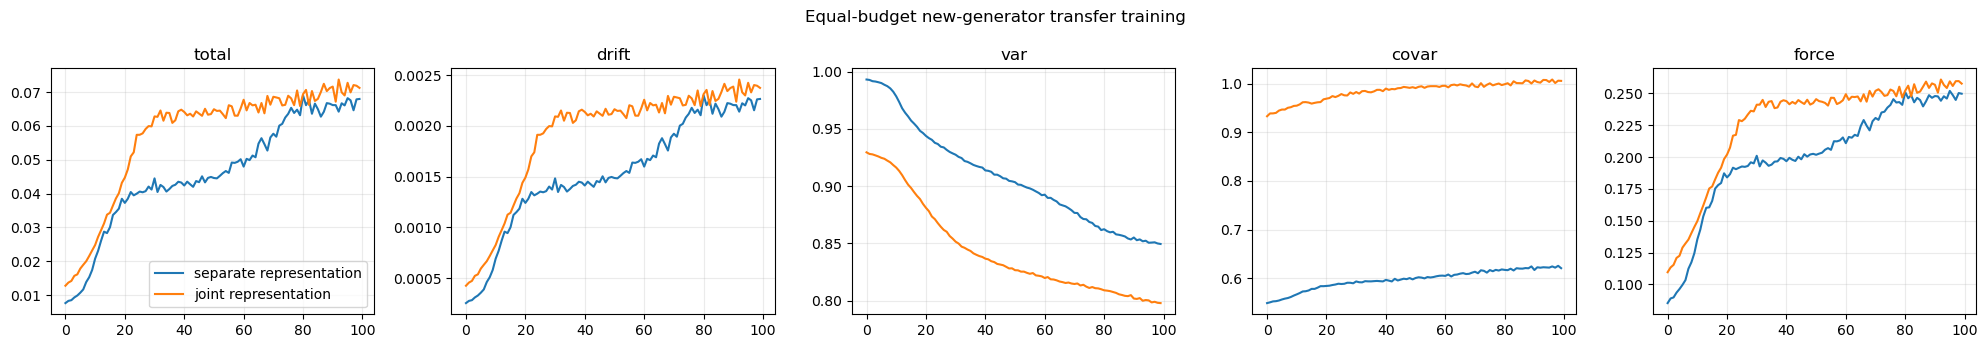

In [10]:
def plot_transfer_histories(separate_history, joint_history):
    keys = ("total", "drift", "var", "covar", "force")
    fig, axes = plt.subplots(1, len(keys), figsize=(20, 3.5))
    for axis, key in zip(axes, keys):
        axis.plot(separate_history[key], label="separate representation")
        axis.plot(joint_history[key], label="joint representation")
        axis.set_title(key)
        axis.grid(alpha=0.25)
    axes[0].legend()
    fig.suptitle("Equal-budget new-generator transfer training")
    fig.tight_layout()
    return fig, axes

plot_transfer_histories(separate_transfer_history, joint_transfer_history)
plt.show()


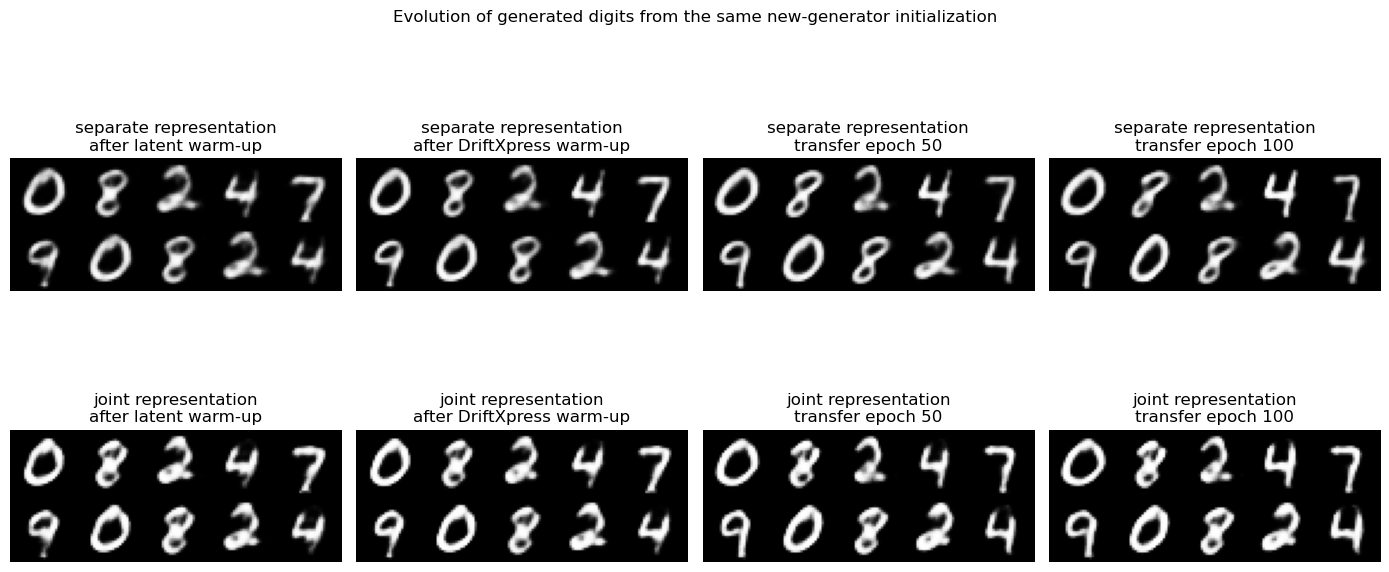

In [11]:
def image_mosaic(images):
    images = np.asarray(images).reshape(-1, 28, 28)
    rows = []
    for start in range(0, len(images), 5):
        row = list(images[start:start + 5])
        while len(row) < 5:
            row.append(np.zeros((28, 28)))
        rows.append(np.hstack(row))
    return np.vstack(rows)


def plot_evolution_comparison(separate_evolution, joint_evolution):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for row, (name, evolution) in enumerate((("separate representation", separate_evolution), ("joint representation", joint_evolution))):
        for column, snapshot in enumerate(evolution[:4]):
            axes[row, column].imshow(image_mosaic(snapshot["images"]), cmap="gray", vmin=0, vmax=1)
            axes[row, column].set_title(f"{name}\n{snapshot['stage']}")
            axes[row, column].axis("off")
    fig.suptitle("Evolution of generated digits from the same new-generator initialization")
    fig.tight_layout()
    return fig, axes

plot_evolution_comparison(separate_evolution, joint_evolution)
plt.show()


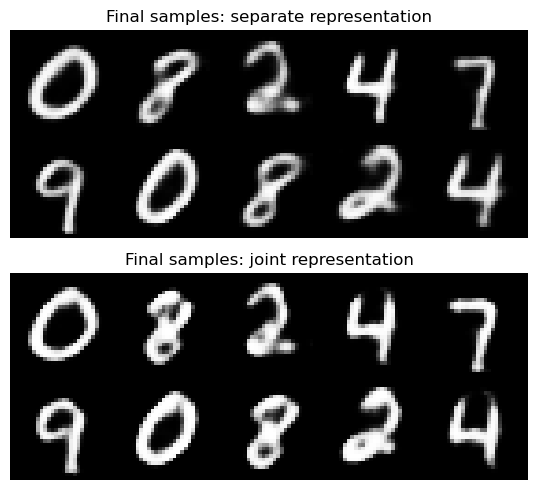

In [12]:
def plot_final_samples(separate_model, joint_model):
    fig, axes = plt.subplots(2, 1, figsize=(14, 5))
    for axis, name, model in ((axes[0], "separate representation", separate_model), (axes[1], "joint representation", joint_model)):
        model.eval()
        with torch.no_grad():
            _, images = model.generate(evolution_noise, evolution_labels)
        axis.imshow(image_mosaic(images.cpu()), cmap="gray", vmin=0, vmax=1)
        axis.set_title(f"Final samples: {name}")
        axis.axis("off")
    fig.tight_layout()
    return fig, axes

plot_final_samples(separate_transfer, joint_transfer)
plt.show()


## How to interpret the comparison

The primary comparison is not the original joint generator versus the separate generator. It is:

- a new generator trained on the frozen separately pretrained representation;
- a new generator trained on the frozen representation produced by fully joint training.

If the joint representation gives lower SWD/FID, reaches the same threshold faster, or has more stable field statistics across seeds, then joint training learned something transferable. If the separate representation wins, then the current evidence supports a stable pretrained encoder rather than unrestricted joint adaptation.

The original co-adapted joint metrics are printed separately only as a diagnostic. They should not be confused with the representation-transfer comparison.
